**DATA HANDLING**

**1. Import Libraries and Load Data**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
# Ensure you have uploaded the file to Colab's local storage
df = pd.read_csv('/content/archive (2).zip')

# Display basic information
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5811 entries, 0 to 5810
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   RecordID             5811 non-null   int64  
 1   AQI                  5811 non-null   float64
 2   PM10                 5811 non-null   float64
 3   PM2_5                5811 non-null   float64
 4   NO2                  5811 non-null   float64
 5   SO2                  5811 non-null   float64
 6   O3                   5811 non-null   float64
 7   Temperature          5811 non-null   float64
 8   Humidity             5811 non-null   float64
 9   WindSpeed            5811 non-null   float64
 10  RespiratoryCases     5811 non-null   int64  
 11  CardiovascularCases  5811 non-null   int64  
 12  HospitalAdmissions   5811 non-null   int64  
 13  HealthImpactScore    5811 non-null   float64
 14  HealthImpactClass    5811 non-null   float64
dtypes: float64(11), int64(4)
memory usage:

,RecordID,AQI,PM10,PM2_5,NO2,SO2,O3,Temperature,Humidity,WindSpeed,RespiratoryCases,CardiovascularCases,HospitalAdmissions,HealthImpactScore,HealthImpactClass
0,1,187.270059,295.853039,13.038560,6.639263,66.161150,54.624280,5.150335,84.424344,6.137755,7,5,1,97.244041,0.0
1,2,475.357153,246.254703,9.984497,16.318326,90.499523,169.621728,1.543378,46.851415,4.521422,10,2,0,100.000000,0.0
2,3,365.996971,84.443191,23.111340,96.317811,17.875850,9.006794,1.169483,17.806977,11.157384,13,3,0,100.000000,0.0
3,4,299.329242,21.020609,14.273403,81.234403,48.323616,93.161033,21.925276,99.473373,15.302500,8,8,1,100.000000,0.0
4,5,78.009320,16.987667,152.111623,121.235461,90.866167,241.795138,9.217517,24.906837,14.534733,9,0,1,95.182643,0.0


**2. Exploratory Data Analysis (EDA)**

Missing Values per Column:
 RecordID               0
AQI                    0
PM10                   0
PM2_5                  0
NO2                    0
SO2                    0
O3                     0
Temperature            0
Humidity               0
WindSpeed              0
RespiratoryCases       0
CardiovascularCases    0
HospitalAdmissions     0
HealthImpactScore      0
HealthImpactClass      0
dtype: int64

Summary Statistics:
           RecordID          AQI         PM10        PM2_5          NO2  \
count  5811.000000  5811.000000  5811.000000  5811.000000  5811.000000   
mean   2906.000000   248.438476   148.654997   100.223714   102.293445   
std    1677.635538   144.777638    85.698500    58.096612    57.713175   
min       1.000000     0.005817     0.015848     0.031549     0.009625   
25%    1453.500000   122.951293    75.374954    49.435171    53.538538   
50%    2906.000000   249.127841   147.634997   100.506337   102.987736   
75%    4358.500000   373.630668   222.436759

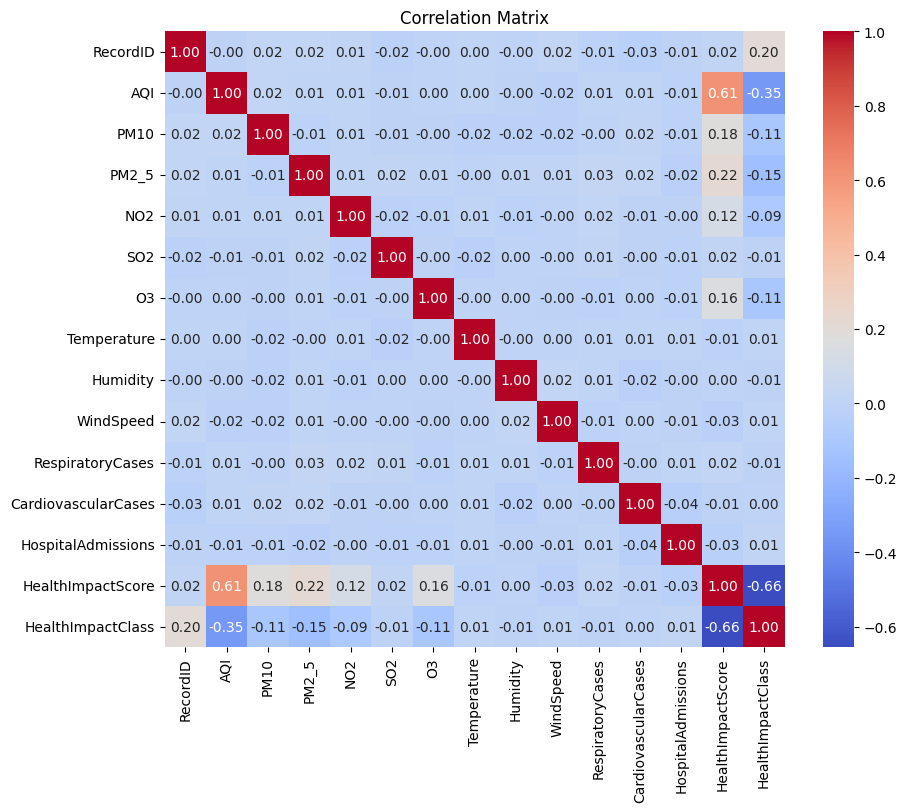

In [ ]:
# Check for missing values
print("Missing Values per Column:\n", df.isnull().sum())

# Statistical summary
print("\nSummary Statistics:\n", df.describe())

# Visualize correlations (useful for feature selection)
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

**3. Handling Missing Values**

In [ ]:
# Option A: Fill missing numerical values with the median
for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].fillna(df[col].median())

# Option B: Fill categorical values with the mode
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after handling:", df.isnull().sum().sum())

Missing values after handling: 0


**4. Encoding Categorical Variables**

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("Encoded Data Preview:")
df.head()

Encoded Data Preview:


,RecordID,AQI,PM10,PM2_5,NO2,SO2,O3,Temperature,Humidity,WindSpeed,RespiratoryCases,CardiovascularCases,HospitalAdmissions,HealthImpactScore,HealthImpactClass
0,1,187.270059,295.853039,13.038560,6.639263,66.161150,54.624280,5.150335,84.424344,6.137755,7,5,1,97.244041,0.0
1,2,475.357153,246.254703,9.984497,16.318326,90.499523,169.621728,1.543378,46.851415,4.521422,10,2,0,100.000000,0.0
2,3,365.996971,84.443191,23.111340,96.317811,17.875850,9.006794,1.169483,17.806977,11.157384,13,3,0,100.000000,0.0
3,4,299.329242,21.020609,14.273403,81.234403,48.323616,93.161033,21.925276,99.473373,15.302500,8,8,1,100.000000,0.0
4,5,78.009320,16.987667,152.111623,121.235461,90.866167,241.795138,9.217517,24.906837,14.534733,9,0,1,95.182643,0.0


**5. Feature Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler

# Assume 'HealthImpactScore' or similar is the target; we scale the features only
X = df.drop('HealthImpactClass', axis=1) # Replace with your actual target column name
y = df['HealthImpactClass']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for readability
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,RecordID,AQI,PM10,PM2_5,NO2,SO2,O3,Temperature,Humidity,WindSpeed,RespiratoryCases,CardiovascularCases,HospitalAdmissions,HealthImpactScore
0,-1.731753,-0.422535,1.717775,-1.500822,-1.657549,0.585544,-1.094322,-0.678448,1.139475,-0.666745,-0.950534,0.004969,-0.715701,0.259715
1,-1.731157,1.567495,1.138971,-1.553395,-1.489825,1.438687,0.234717,-0.927516,-0.304607,-0.946559,0.008250,-1.348455,-1.430664,0.466653
2,-1.730561,0.812063,-0.749340,-1.327427,-0.103549,-1.107022,-1.621528,-0.953334,-1.420905,0.202236,0.967033,-0.897314,-1.430664,0.466653
3,-1.729964,0.351540,-1.489470,-1.479565,-0.364923,-0.039723,-0.648948,0.479897,1.717872,0.919824,-0.630939,1.358392,-0.715701,0.466653
4,-1.729368,-1.177280,-1.536534,0.893208,0.328238,1.451539,1.068833,-0.397601,-1.148028,0.786911,-0.311345,-2.250738,-0.715701,0.104929


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separate Features (X) and Target (y)
# Replace 'HealthImpactClass' with the exact name of your target column
X = df.drop('HealthImpactClass', axis=1)
y = df['HealthImpactClass']

# 2. Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Create the Train/Test Split
# This defines X_train, X_test, y_train, and y_test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# 4. Verify they exist
print("X_train successfully defined!")
print(f"Training samples: {len(X_train)}")

X_train successfully defined!
Training samples: 4648


** *italicized *italicized text* text*GRADIENT DESCENT MODEL IMPLEMENTATION**

**1. Initialize and Train the Model**

In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize the Stochastic Gradient Descent model
# 'loss=log_loss' performs Logistic Regression
# 'max_iter' is the number of passes over the data (epochs)
sgd_model = SGDClassifier(loss='log_loss', max_iter=1000, random_state=42)

# Train the model using the training data
sgd_model.fit(X_train, y_train)

print("Gradient Descent model training complete!")

Gradient Descent model training complete!


**2. Make Predictions and Evaluate**

> Add blockquote



In [ ]:
# Use the trained model to predict the test set
y_pred = sgd_model.predict(X_test)

# Calculate the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# Detailed Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Model Accuracy: 90.11%

Classification Report:

              precision    recall  f1-score   support

         0.0       0.95      0.98      0.97       953
         1.0       0.63      0.85      0.72       124
         2.0       0.44      0.08      0.13        53
         3.0       0.00      0.00      0.00        20
         4.0       0.00      0.00      0.00        13

    accuracy                           0.90      1163
   macro avg       0.41      0.38      0.36      1163
weighted avg       0.87      0.90      0.88      1163



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**3. Visualizing the Iterative Process**

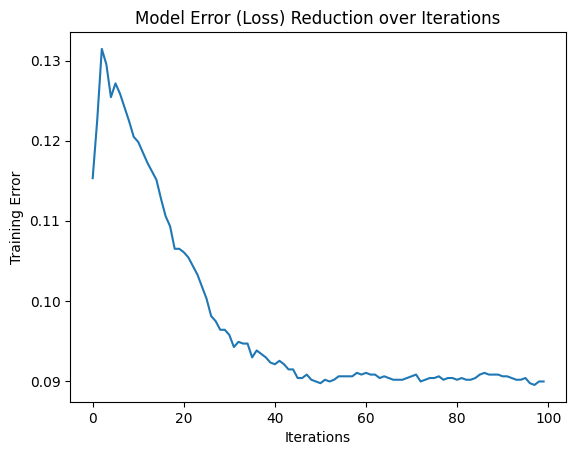

In [ ]:
# Re-training with a manual loop to capture the loss over iterations
losses = []
sgd_plot = SGDClassifier(loss='log_loss', warm_start=True, random_state=42)

for i in range(1, 101):
    sgd_plot.partial_fit(X_train, y_train, classes=np.unique(y_train))
    # Approximation of the loss for visualization
    losses.append(1 - sgd_plot.score(X_train, y_train))

plt.plot(losses)
plt.title("Model Error (Loss) Reduction over Iterations")
plt.xlabel("Iterations")
plt.ylabel("Training Error")
plt.show()

**Hyperparameter Tuning for Gradient Descent**

In [ ]:
param_grid_sgd = {
    'alpha': [0.0001, 0.001, 0.01],  # Learning rate regularization
    'penalty': ['l2', 'l1'],         # Type of regularization
    'max_iter': [1000, 2000]         # Iterations
}

grid_search_sgd = GridSearchCV(SGDClassifier(loss='log_loss', random_state=42),
                               param_grid_sgd, cv=3)

grid_search_sgd.fit(X_train, y_train)

print("Best SGD Parameters:", grid_search_sgd.best_params_)

Best SGD Parameters: {'alpha': 0.001, 'max_iter': 1000, 'penalty': 'l1'}


**RANDOM FOREST**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Initialize the Random Forest
# n_estimators=100 means the forest will have 100 individual decision trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the model
rf_model.fit(X_train, y_train)

# 3. Make predictions
y_pred_rf = rf_model.predict(X_test)

# 4. Evaluate performance
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf) * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 95.70%

Classification Report:
               precision    recall  f1-score   support

         0.0       0.98      1.00      0.99       953
         1.0       0.92      0.91      0.91       124
         2.0       0.79      0.79      0.79        53
         3.0       0.73      0.40      0.52        20
         4.0       0.00      0.00      0.00        13

    accuracy                           0.96      1163
   macro avg       0.68      0.62      0.64      1163
weighted avg       0.95      0.96      0.95      1163



**Visualizing Feature Importance**

*   List item
*   List item



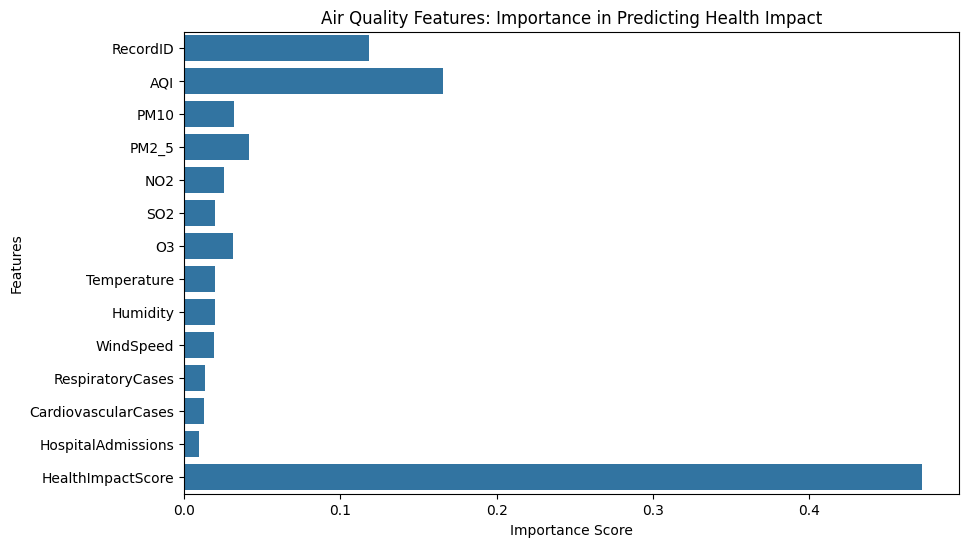

In [ ]:
# Extract feature importance
importances = rf_model.feature_importances_
feature_names = X.columns # Using the original feature names from your dataframe

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=feature_names)
plt.title("Air Quality Features: Importance in Predicting Health Impact")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

\**Hyperparameter Tuning for Random Forest**

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the "Grid" of parameters you want to test
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees
    'max_depth': [None, 10, 20],      # How deep the trees go
    'min_samples_split': [2, 5]       # Minimum data points to split a node
}

# Initialize the Grid Search
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=3, n_jobs=-1, verbose=2)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Print the best parameters found
print("Best Parameters:", grid_search.best_params_)

# Use the best model for final predictions
best_rf_model = grid_search.best_estimator_

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}


**Comparison of "Before" vs. "After" Tuning**

In [ ]:
# Evaluate the tuned Random Forest
tuned_pred = best_rf_model.predict(X_test)
tuned_accuracy = accuracy_score(y_test, tuned_pred)

print(f"Original Accuracy: {accuracy * 100:.2f}%") # From your previous code
print(f"Tuned Accuracy: {tuned_accuracy * 100:.2f}%")

Original Accuracy: 90.11%
Tuned Accuracy: 95.79%


In [ ]:
# Test 1: Random Forest with 100 Trees
rf_100 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_100.fit(X_train, y_train)
acc_100 = rf_100.score(X_test, y_test)

# Test 2: Random Forest with 200 Trees
rf_200 = RandomForestClassifier(n_estimators=200, random_state=42)
rf_200.fit(X_train, y_train)
acc_200 = rf_200.score(X_test, y_test)

print(f"Accuracy with 100 trees: {acc_100 * 100:.2f}%")
print(f"Accuracy with 200 trees: {acc_200 * 100:.2f}%")

Accuracy with 100 trees: 95.70%
Accuracy with 200 trees: 95.61%
